<a href="https://colab.research.google.com/github/jhonn18git/inteligencia-artificial-1-ia/blob/main/laboratorios/lab1/lab_1_regresion_miltivariable.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

REGRESION MULTIVARIABLE

---
### Explicación del laboratorio – Regresión lineal multivariable

En este laboratorio se aplicó un modelo de **regresión lineal multivariable** para predecir el precio de alojamientos utilizando un dataset de Airbnb de la ciudad de Nueva York. El dataset contiene información sobre diferentes propiedades, incluyendo variables relacionadas con la disponibilidad, número de reseñas y noches mínimas requeridas.

El objetivo principal del modelo es **predecir el precio de un alojamiento** a partir de varias características. Para este propósito se seleccionaron las siguientes variables como características de entrada:

* **minimum_nights:** número mínimo de noches requeridas para reservar el alojamiento.
* **number_of_reviews:** cantidad de reseñas que tiene el alojamiento.
* **reviews_per_month:** promedio de reseñas que recibe el alojamiento por mes.
* **availability_365:** número de días al año en los que el alojamiento está disponible.

La variable objetivo del modelo es:

* **price:** precio del alojamiento.

Primero se realizó la **normalización de las características**, lo cual consiste en restar la media de cada variable y dividir por su desviación estándar. Este paso es importante porque las variables pueden tener escalas muy diferentes, y la normalización ayuda a que el algoritmo de entrenamiento funcione de forma más estable y rápida.

Posteriormente se implementó el algoritmo de **descenso de gradiente**, el cual se utiliza para encontrar los parámetros del modelo (theta) que minimizan el error entre los valores predichos por el modelo y los valores reales del dataset. Durante el entrenamiento se calcula la función de costo, la cual mide qué tan bien está funcionando el modelo. A medida que el algoritmo itera, el valor del costo disminuye, lo que indica que el modelo está aprendiendo.

También se generó un **gráfico de convergencia del costo**, el cual permite visualizar cómo el error del modelo disminuye a medida que aumentan las iteraciones del algoritmo.

Además, se realizaron diferentes visualizaciones de los datos utilizando gráficos de dispersión (scatter plots), donde cada punto representa un alojamiento del dataset. Estos gráficos permiten observar la relación entre las diferentes características y el precio, así como comparar los valores reales con los valores predichos por el modelo.

Finalmente, se utilizó el modelo entrenado para realizar una **predicción del precio de un nuevo alojamiento**, utilizando valores específicos de las variables seleccionadas. Esto demuestra cómo el modelo puede utilizarse para estimar precios de propiedades basándose en sus características.

En conclusión, este laboratorio permitió comprender el funcionamiento de la regresión lineal multivariable, así como el proceso completo de preparación de datos, entrenamiento del modelo, evaluación mediante la función de costo y visualización de resultados.



In [4]:
# Importamos las librerías necesarias
import numpy as np          # Librería para cálculos numéricos y álgebra lineal
import pandas as pd         # Librería para manejo de datos en forma de tablas (DataFrames)
from matplotlib import pyplot  # Librería para gráficos

In [5]:
# Montamos Google Drive para acceder a archivos desde Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd
# Leemos el dataset de Airbnb de NYC
data = pd.read_csv('/content/drive/MyDrive/colab/lab1/AB_NYC_2019.csv')

# Mostramos las primeras filas para entender la estructura de los datos

print("Primeras filas del dataset:")
display(data.head())

Primeras filas del dataset:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [7]:
# Eliminamos filas con valores faltantes (NaN)

data = data.dropna()

In [8]:
# Seleccionamos las características (X) y la variable objetivo (y)
X = data[['minimum_nights','number_of_reviews','reviews_per_month','availability_365']].values
y = data['price'].values

m = y.size

print("Cantidad de ejemplos:", m)
print("Primeros datos de X:")
print(X[:5])

Cantidad de ejemplos: 38821
Primeros datos de X:
[[1.00e+00 9.00e+00 2.10e-01 3.65e+02]
 [1.00e+00 4.50e+01 3.80e-01 3.55e+02]
 [1.00e+00 2.70e+02 4.64e+00 1.94e+02]
 [1.00e+01 9.00e+00 1.00e-01 0.00e+00]
 [3.00e+00 7.40e+01 5.90e-01 1.29e+02]]


In [9]:
def normalizarCaracteristicas(X):
#    Normaliza cada columna de X restando la media y dividiendo por la desviación estándar.

    X_norm = X.copy()

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [10]:
# Normalizamos las características

X_norm, mu, sigma = normalizarCaracteristicas(X)

print("Media:", mu)
print("Desviación estándar:", sigma)

Media: [  5.86922027  29.29025527   1.37322918 114.88629865]
Desviación estándar: [ 17.38880228  48.18227934   1.68030613 129.52828165]


In [11]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = normalizarCaracteristicas(X)
# Mostramos los resultados de la normalización

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[1.00e+00 9.00e+00 2.10e-01 3.65e+02]
 [1.00e+00 4.50e+01 3.80e-01 3.55e+02]
 [1.00e+00 2.70e+02 4.64e+00 1.94e+02]
 ...
 [1.00e+00 1.00e+00 1.00e+00 8.70e+01]
 [1.00e+00 2.00e+00 2.00e+00 4.00e+01]
 [1.00e+00 1.00e+00 1.00e+00 1.00e+00]]
Media calculada: [  5.86922027  29.29025527   1.37322918 114.88629865]
Desviación estandar calculada: [ 17.38880228  48.18227934   1.68030613 129.52828165]
[[-0.28002045 -0.42111448 -0.69227218  1.93095823]
 [-0.28002045  0.32604818 -0.59110014  1.85375501]
 [-0.28002045  4.99581481  1.94415218  0.61078322]
 ...
 [-0.28002045 -0.58715062 -0.22211975 -0.2152912 ]
 [-0.28002045 -0.5663961   0.3730099  -0.57814631]
 [-0.28002045 -0.58715062 -0.22211975 -0.87923886]]


In [12]:
# Función para calcular el costo de regresión lineal

def calcularCosto(X, y, theta):
#    Calcula el costo J para regresión lineal.

    m = y.size

    J = (1/(2*m)) * np.sum(np.square(np.dot(X,theta) - y))

    return J

In [13]:
# Función para realizar el descenso de gradiente

def calcularDescensoGradiente(X, y, theta, alpha, iteraciones):
#    Aplica el descenso de gradiente para minimizar la función de costo.

    m = y.shape[0]

    theta = theta.copy()

    J_hist = []

    for i in range(iteraciones):

        theta = theta - (alpha/m) * (np.dot(X,theta) - y).dot(X)

        J_hist.append(calcularCosto(X,y,theta))

    return theta, J_hist

In [14]:
# Preparamos X agregando una columna de 1s para el término independiente (theta_0)

X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
# Inicializamos theta en ceros

theta = np.zeros(X_ready.shape[1])
# Parámetros del descenso de gradiente

alpha = 0.01
iteraciones = 1000
# Ejecutamos el descenso de gradiente

theta, J_hist = calcularDescensoGradiente(X_ready, y, theta, alpha, iteraciones)

print("Theta calculado:")
print(theta)

Theta calculado:
[142.32638154   2.11747304  -7.66414117  -4.83617412  17.58260995]


In [15]:
# Revisamos X ya lista para el modelo

X_ready

array([[ 1.        , -0.28002045, -0.42111448, -0.69227218,  1.93095823],
       [ 1.        , -0.28002045,  0.32604818, -0.59110014,  1.85375501],
       [ 1.        , -0.28002045,  4.99581481,  1.94415218,  0.61078322],
       ...,
       [ 1.        , -0.28002045, -0.58715062, -0.22211975, -0.2152912 ],
       [ 1.        , -0.28002045, -0.5663961 ,  0.3730099 , -0.57814631],
       [ 1.        , -0.28002045, -0.58715062, -0.22211975, -0.87923886]])

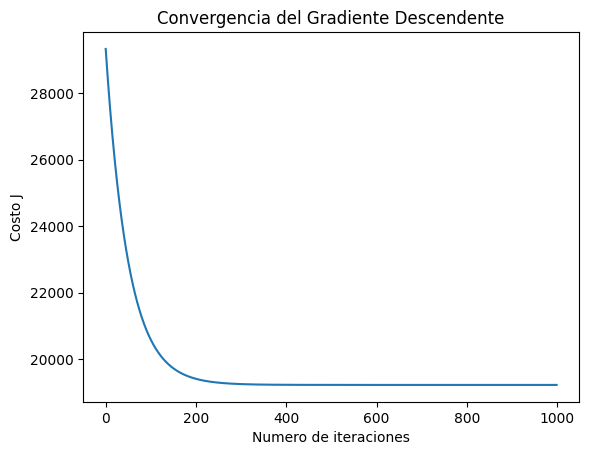

In [16]:
# Graficamos la convergencia del costo

pyplot.plot(np.arange(len(J_hist)), J_hist)
pyplot.xlabel("Numero de iteraciones")
pyplot.ylabel("Costo J")
pyplot.title("Convergencia del Gradiente Descendente")
pyplot.show()

In [17]:
# Predicción para un nuevo ejemplo
xp = np.array([
    1,                          # Término independiente
    (3 - mu[0]) / sigma[0],     # minimum_nights normalizado
    (10 - mu[1]) / sigma[1],    # number_of_reviews normalizado
    (1 - mu[2]) / sigma[2],     # reviews_per_month normalizado
    (200 - mu[3]) / sigma[3]    # availability_365 normalizado
])

precio = np.dot(xp, theta)
print("Precio predicho:", precio)

Precio predicho: 157.67323884677526


In [18]:
# Mostramos el costo final después de entrenar

print("Costo final:", J_hist[-1])

Costo final: 19220.340090809234


In [19]:
import numpy as np

# Datos de ejemplo
# tamaño(m2), habitaciones, edad(años)

X = np.array([
    [50, 2, 20],
    [80, 3, 15],
    [120, 4, 5],
    [60, 2, 30],
    [100, 3, 8]
])

# Precio de cada casa (en miles de dólares)
y = np.array([120, 200, 350, 150, 300])

print("Datos originales X:")
print(X)
print("Precios y:")
print(y)

Datos originales X:
[[ 50   2  20]
 [ 80   3  15]
 [120   4   5]
 [ 60   2  30]
 [100   3   8]]
Precios y:
[120 200 350 150 300]


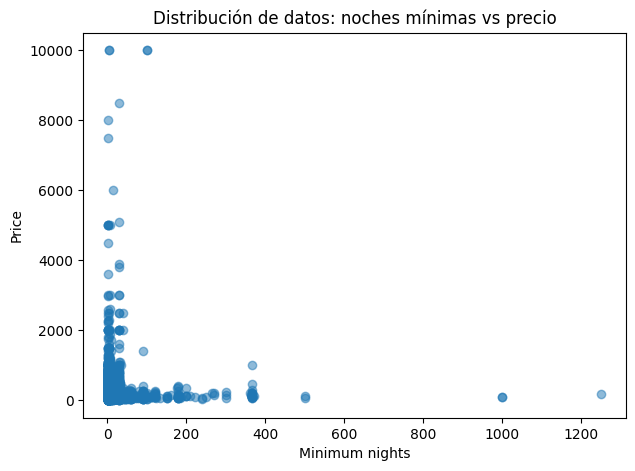

In [20]:
# =====================================================
# GRÁFICO DE DATOS (PUNTOS)
# =====================================================
# Representamos una de las variables contra el precio
# para visualizar cómo se distribuyen los datos

pyplot.figure(figsize=(7,5))

pyplot.scatter(data['minimum_nights'], data['price'], alpha=0.5)

pyplot.xlabel("Minimum nights")
pyplot.ylabel("Price")
pyplot.title("Distribución de datos: noches mínimas vs precio")

pyplot.show()

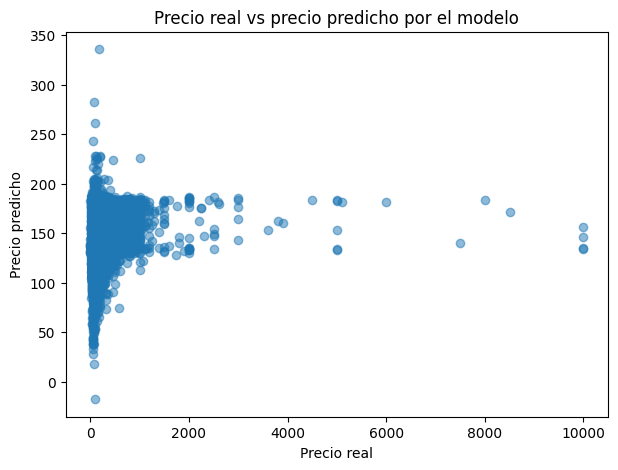

In [23]:
# =====================================================
# COMPARACIÓN PRECIO REAL VS PRECIO PREDICHO
# =====================================================

# Redefinimos 'y' para que corresponda con el dataset de Airbnb
y = data['price'].values

# Calculamos predicciones para todos los datos
predicciones = np.dot(X_ready, theta)

pyplot.figure(figsize=(7,5))

pyplot.scatter(y, predicciones, alpha=0.5)

pyplot.xlabel("Precio real")
pyplot.ylabel("Precio predicho")
pyplot.title("Precio real vs precio predicho por el modelo")

pyplot.show()

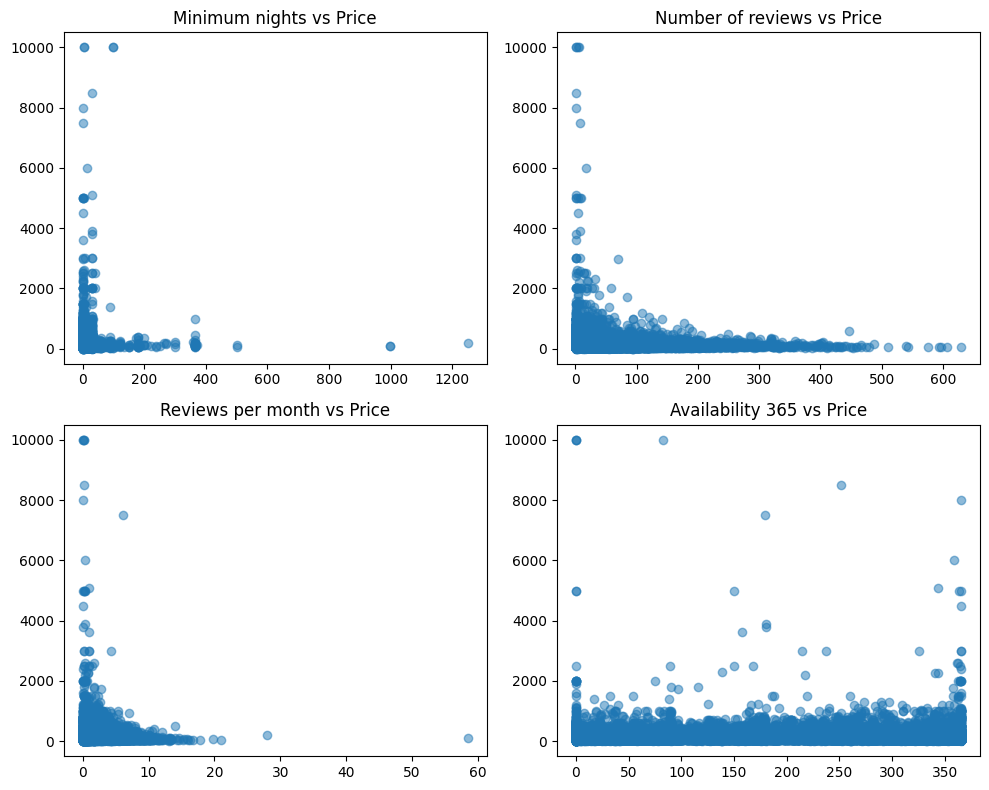

In [24]:
# =====================================================
# RELACIÓN ENTRE VARIABLES Y PRECIO
# =====================================================

fig, axs = pyplot.subplots(2,2, figsize=(10,8))

axs[0,0].scatter(data['minimum_nights'], y, alpha=0.5)
axs[0,0].set_title("Minimum nights vs Price")

axs[0,1].scatter(data['number_of_reviews'], y, alpha=0.5)
axs[0,1].set_title("Number of reviews vs Price")

axs[1,0].scatter(data['reviews_per_month'], y, alpha=0.5)
axs[1,0].set_title("Reviews per month vs Price")

axs[1,1].scatter(data['availability_365'], y, alpha=0.5)
axs[1,1].set_title("Availability 365 vs Price")

pyplot.tight_layout()
pyplot.show()

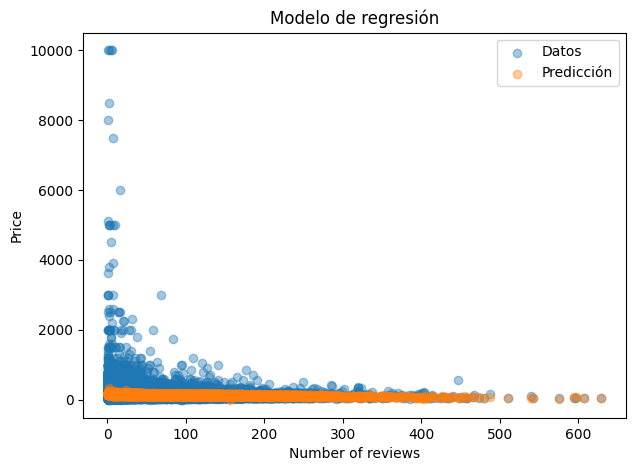

In [25]:
# =====================================================
# DATOS + MODELO DE REGRESIÓN
# =====================================================

pyplot.figure(figsize=(7,5))

pyplot.scatter(data['number_of_reviews'], y, alpha=0.4, label="Datos")

pyplot.scatter(data['number_of_reviews'], predicciones, alpha=0.4, label="Predicción")

pyplot.xlabel("Number of reviews")
pyplot.ylabel("Price")
pyplot.title("Modelo de regresión")

pyplot.legend()

pyplot.show()

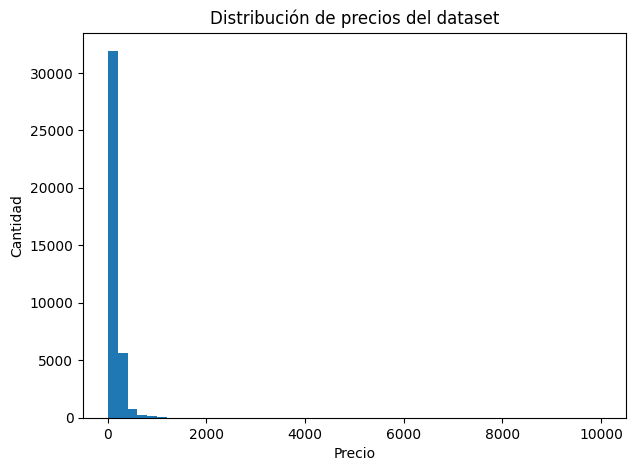

In [26]:
# =====================================================
# DISTRIBUCIÓN DE PRECIOS
# =====================================================

pyplot.figure(figsize=(7,5))

pyplot.hist(y, bins=50)

pyplot.xlabel("Precio")
pyplot.ylabel("Cantidad")
pyplot.title("Distribución de precios del dataset")

pyplot.show()